<a href="https://colab.research.google.com/github/hoshi-3104-com/california-house-price-competition/blob/main/notebooks/06_house_price_after_preprocess_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# driveのマウント
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Kaggle APIを利用できるようにするため、kaggle.jsonからusernameとkeyを設定する
import os
import json
f = open("/content/drive/MyDrive/house_price_competion_hoshino/kaggle.json", 'r') # ディレクトリは必要に応じて変更してください
json_data = json.load(f)
os.environ['KAGGLE_USERNAME'] = json_data['username']
os.environ['KAGGLE_KEY'] = json_data['key']

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# 前処理(正規化・標準化)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.linear_model import LinearRegression

# 精度評価
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

#### ①外れ値除去のみ処理後の予測

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*X does not have valid feature names.*')

import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor

# 0. Optunaで得られたベストパラメータの定義
best_params = {
    'lambda_l1': 4.890094087336637e-05,
    'lambda_l2': 3.458995503983615e-07,
    'num_leaves': 89,
    'max_depth': 10,
    'bagging_fraction': 0.9341899691615144,
    'bagging_freq': 5,
    'min_child_samples': 19,
    'random_state': 42,
    'verbose': -1
}

train = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/1_preprocess_train_data_excluding_outliers.csv')
test = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/test_data_raw.csv')
sample = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/sample_raw.csv')

# 1. データの切り分け
X_all_train = train.drop(["Price" ,"id"], axis=1, errors='ignore')
y_all_train = train["Price"]
X_test = test.drop(["id"], axis=1) if "id" in test.columns else test

print("データ分割前の行数:", len(X_all_train))

# 2. クロスバリデーションおよびRFEの設定
folds_num = 5
kf = KFold(n_splits=folds_num, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test))
cv_scores = []

# 3. クロスバリデーションのループ処理
for fold, (cv_train_idx, cv_val_idx) in enumerate(kf.split(X_all_train, y_all_train)):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    # RFEによる特徴量選択（ベースモデルはデフォルトのままでOK）
    print(f"Fold {fold + 1}: RFEによる特徴量選択中...")
    rfe_base_model = LGBMRegressor(random_state=42, verbose=-1)
    rfe_selector = RFE(estimator=rfe_base_model, step=1)
    rfe_selector.fit(X_cv_train, y_cv_train)

    X_cv_train_selected = rfe_selector.transform(X_cv_train)
    X_cv_val_selected = rfe_selector.transform(X_cv_val)
    X_test_selected = rfe_selector.transform(X_test)

    # 4. 【変更点】ベストパラメータを適用してモデルを学習
    model = LGBMRegressor(**best_params)
    model.fit(X_cv_train_selected, y_cv_train)

    # 5. 検証データに対する予測と逆変換
    val_preds = model.predict(X_cv_val_selected)

    val_preds = np.where(val_preds <= 0, 0, val_preds)
    val_preds = np.where(val_preds >= 5.00001, 5.00001, val_preds)
    oof_predictions[cv_val_idx] = val_preds

    # 6. テストデータに対する予測と逆変換
    test_preds = model.predict(X_test_selected)

    test_preds = np.where(test_preds <= 0, 0, test_preds)
    test_preds = np.where(test_preds >= 5.00001, 5.00001, test_preds)
    test_predictions += test_preds / folds_num

    # 7. スコアを記録
    y_cv_val_original = train["Price"].iloc[cv_val_idx]
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val_original, val_preds))
    cv_scores.append(fold_rmse)
    print(f"Fold {fold + 1} の検証スコア (RMSE): {fold_rmse:.4f}")

# 8. クロスバリデーション全体の評価スコア算出
print("\n==================================")
print(f"各Foldの平均スコア: {np.mean(cv_scores):.4f}")
overall_oof_score = np.sqrt(mean_squared_error(train["Price"], oof_predictions))
print(f"全体のOOFスコア (RMSE): {overall_oof_score:.4f}")
print("==================================")

# 9. 提出用ファイルの作成
sample["Price"] = test_predictions

データ分割前の行数: 16506
--- Fold 1 / 5 開始 ---
Fold 1: RFEによる特徴量選択中...
Fold 1 の検証スコア (RMSE): 0.4654
--- Fold 2 / 5 開始 ---
Fold 2: RFEによる特徴量選択中...
Fold 2 の検証スコア (RMSE): 0.4668
--- Fold 3 / 5 開始 ---
Fold 3: RFEによる特徴量選択中...
Fold 3 の検証スコア (RMSE): 0.4937
--- Fold 4 / 5 開始 ---
Fold 4: RFEによる特徴量選択中...
Fold 4 の検証スコア (RMSE): 0.4471
--- Fold 5 / 5 開始 ---
Fold 5: RFEによる特徴量選択中...
Fold 5 の検証スコア (RMSE): 0.4651

各Foldの平均スコア: 0.4676
全体のOOFスコア (RMSE): 0.4679


In [ ]:
sample.to_csv('submit_house_price_add_features_and_optuna.csv', index=False)

In [ ]:
# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_add_features_and_optuna.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.0k/94.0k [00:00<00:00, 101kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

#### ②特徴量の追加

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*X does not have valid feature names.*')

import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor

# 0. Optunaで得られたベストパラメータの定義
best_params = {
    'lambda_l1': 4.890094087336637e-05,
    'lambda_l2': 3.458995503983615e-07,
    'num_leaves': 89,
    'max_depth': 10,
    'bagging_fraction': 0.9341899691615144,
    'bagging_freq': 5,
    'min_child_samples': 19,
    'random_state': 42,
    'verbose': -1
}

train = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/2_preprocess_train_data_add_feature.csv')
test = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/1_preprocess_test_data_add_feature.csv')
sample = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/sample_raw.csv')

# 1. データの切り分け
X_all_train = train.drop(["Price" ,"id"], axis=1, errors='ignore')
y_all_train = train["Price"]
X_test = test.drop(["id"], axis=1) if "id" in test.columns else test

print("データ分割前の行数:", len(X_all_train))

# 2. クロスバリデーションおよびRFEの設定
folds_num = 5
kf = KFold(n_splits=folds_num, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test))
cv_scores = []

# 3. クロスバリデーションのループ処理
for fold, (cv_train_idx, cv_val_idx) in enumerate(kf.split(X_all_train, y_all_train)):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    # RFEによる特徴量選択（ベースモデルはデフォルトのままでOK）
    print(f"Fold {fold + 1}: RFEによる特徴量選択中...")
    rfe_base_model = LGBMRegressor(random_state=42, verbose=-1)
    rfe_selector = RFE(estimator=rfe_base_model, step=1)
    rfe_selector.fit(X_cv_train, y_cv_train)

    X_cv_train_selected = rfe_selector.transform(X_cv_train)
    X_cv_val_selected = rfe_selector.transform(X_cv_val)
    X_test_selected = rfe_selector.transform(X_test)

    # 4. 【変更点】ベストパラメータを適用してモデルを学習
    model = LGBMRegressor(**best_params)
    model.fit(X_cv_train_selected, y_cv_train)

    # 5. 検証データに対する予測と逆変換
    val_preds = model.predict(X_cv_val_selected)

    val_preds = np.where(val_preds <= 0, 0, val_preds)
    val_preds = np.where(val_preds >= 5.00001, 5.00001, val_preds)
    oof_predictions[cv_val_idx] = val_preds

    # 6. テストデータに対する予測と逆変換
    test_preds = model.predict(X_test_selected)

    test_preds = np.where(test_preds <= 0, 0, test_preds)
    test_preds = np.where(test_preds >= 5.00001, 5.00001, test_preds)
    test_predictions += test_preds / folds_num

    # 7. スコアを記録
    y_cv_val_original = train["Price"].iloc[cv_val_idx]
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val_original, val_preds))
    cv_scores.append(fold_rmse)
    print(f"Fold {fold + 1} の検証スコア (RMSE): {fold_rmse:.4f}")

# 8. クロスバリデーション全体の評価スコア算出
print("\n==================================")
print(f"各Foldの平均スコア: {np.mean(cv_scores):.4f}")
overall_oof_score = np.sqrt(mean_squared_error(train["Price"], oof_predictions))
print(f"全体のOOFスコア (RMSE): {overall_oof_score:.4f}")
print("==================================")

# 9. 提出用ファイルの作成
sample["Price"] = test_predictions

データ分割前の行数: 16506
--- Fold 1 / 5 開始 ---
Fold 1: RFEによる特徴量選択中...
Fold 1 の検証スコア (RMSE): 0.4435
--- Fold 2 / 5 開始 ---
Fold 2: RFEによる特徴量選択中...
Fold 2 の検証スコア (RMSE): 0.4361
--- Fold 3 / 5 開始 ---
Fold 3: RFEによる特徴量選択中...
Fold 3 の検証スコア (RMSE): 0.4638
--- Fold 4 / 5 開始 ---
Fold 4: RFEによる特徴量選択中...
Fold 4 の検証スコア (RMSE): 0.4297
--- Fold 5 / 5 開始 ---
Fold 5: RFEによる特徴量選択中...
Fold 5 の検証スコア (RMSE): 0.4342

各Foldの平均スコア: 0.4415
全体のOOFスコア (RMSE): 0.4416


In [ ]:
!pip install shap

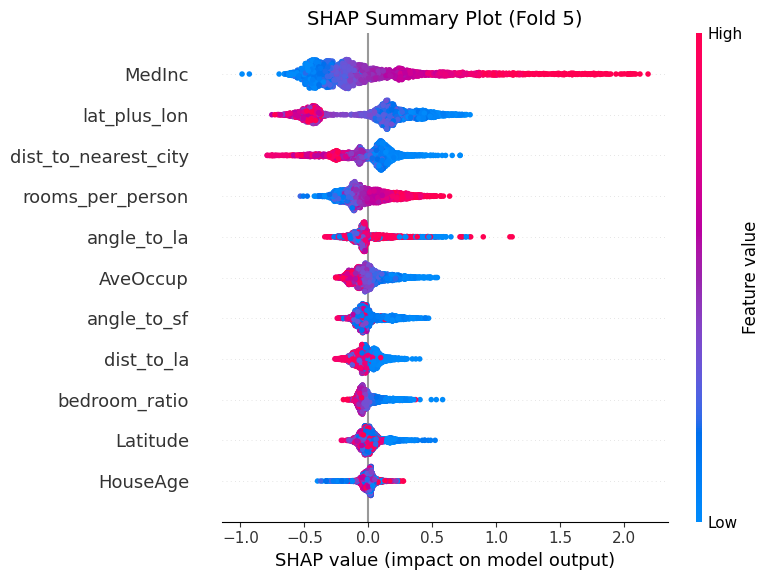

In [ ]:
import shap

# 1. 最後のFoldで選ばれた特徴量名を取得し、NumPy配列をDataFrameに戻す（文字化け・名前落ち防止）
selected_features = X_all_train.columns[rfe_selector.support_]
X_cv_val_df = pd.DataFrame(X_cv_val_selected, columns=selected_features)

# 2. SHAP値の計算（TreeExplainerを使用）
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_cv_val_df)

# 3. SHAP Summary Plotの描画
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_cv_val_df,max_display=len(selected_features), show=False)
plt.title(f"SHAP Summary Plot (Fold {fold + 1})", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
sample.to_csv('submit_house_price_add_features_and_optuna.csv', index=False)

In [ ]:
# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_add_features_and_optuna.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.0k/94.0k [00:00<00:00, 130kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

#### まず、対数変換したpriceを予測するモデル作り・評価を行う

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*X does not have valid feature names.*')

import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor

train = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/3_preprocess_train_data_translate_log&box-cox.csv')
test = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/1_preprocess_test_data_add_feature.csv')
sample = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/sample_raw.csv')

# 1. データの切り分け
X_all_train = train.drop(["Price", "Log_Price","BoxCox_Price" ,"id"], axis=1, errors='ignore')
y_all_train = train["Log_Price"]
X_test = test.drop(["id"], axis=1) if "id" in test.columns else test

print("データ分割前の行数:", len(X_all_train))

import warnings
warnings.filterwarnings('ignore', message='.*X does not have valid feature names.*')

import numpy as np
import pandas as pd
from sklearn.feature_selection import RFECV  # RFECVを使用
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor

# 0. Optunaで得られたベストパラメータの定義
best_params = {
    'lambda_l1': 4.890094087336637e-05,
    'lambda_l2': 3.458995503983615e-07,
    'num_leaves': 89,
    'max_depth': 10,
    'bagging_fraction': 0.9341899691615144,
    'bagging_freq': 5,
    'min_child_samples': 19,
    'random_state': 42,
    'verbose': -1
}

# --- ターゲット変数の対数変換 ---
train['Log_Price'] = np.log(train['Price'])

# 1. データの切り分け
X_all_train = train.drop(["Price", "Log_Price", "BoxCox_Price", "id"], axis=1, errors='ignore')
y_all_train = train["Log_Price"]  # ターゲットは対数スケール
X_test = test.drop(["id"], axis=1) if "id" in test.columns else test

print("データ分割前の行数:", len(X_all_train))

# --- [改善] ループの前に、自動で最適な特徴量を厳選する ---
print("\n--- RFECVによる最適な特徴量の自動探索を開始 ---")
rfecv_base_model = LGBMRegressor(random_state=42, verbose=-1)

# 対数スケール上でのRMSE（負の値）を最大化する方向で探索
rfecv_selector = RFECV(
    estimator=rfecv_base_model,
    step=1,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rfecv_selector.fit(X_all_train, y_all_train)

# 生き残った最適な特徴量の列名を取得
selected_features = X_all_train.columns[rfecv_selector.support_].tolist()
print(f"元の特徴量数: {X_all_train.shape[1]}")
print(f"自動選択された最適な特徴量数: {len(selected_features)}")
print(f"選択された特徴量: {selected_features}")
print("---------------------------------------------\n")

# 2. クロスバリデーションの設定
folds_num = 5
kf = KFold(n_splits=folds_num, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test))
cv_scores = []

# 3. クロスバリデーションのループ処理
for fold, (cv_train_idx, cv_val_idx) in enumerate(kf.split(X_all_train, y_all_train)):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    # RFECVで厳選された特徴量（selected_features）だけを切り出す
    X_cv_train = X_all_train.iloc[cv_train_idx][selected_features]
    y_cv_train = y_all_train.iloc[cv_train_idx]
    X_cv_val = X_all_train.iloc[cv_val_idx][selected_features]
    y_cv_val = y_all_train.iloc[cv_val_idx]

    X_test_selected = X_test[selected_features]

    # 4. ベストパラメータを適用してモデルを学習（ターゲットは対数）
    model = LGBMRegressor(**best_params)
    model.fit(X_cv_train, y_cv_train)

    # 5. 検証データに対する予測と逆変換（指数戻し）
    val_preds_log = model.predict(X_cv_val)
    val_preds = np.expm1(val_preds_log)  # 元の価格スケールに戻す

    # 元のスケールに戻した後にクリッピング
    val_preds = np.clip(val_preds, 0, 5.00001)
    oof_predictions[cv_val_idx] = val_preds

    # 6. テストデータに対する予測と逆変換（指数戻し）
    test_preds_log = model.predict(X_test_selected)
    test_preds = np.expm1(test_preds_log)  # 元の価格スケールに戻す

    test_preds = np.clip(test_preds, 0, 5.00001)
    test_predictions += test_preds / folds_num

    # 7. スコアを記録（元のPriceスケールでRMSEを評価）
    y_cv_val_original = train["Price"].iloc[cv_val_idx]
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val_original, val_preds))
    cv_scores.append(fold_rmse)
    print(f"Fold {fold + 1} の検証スコア (RMSE): {fold_rmse:.4f}")

# 8. クロスバリデーション全体の評価スコア算出
print("\n==================================")
print(f"各Foldの平均スコア: {np.mean(cv_scores):.4f}")
overall_oof_score = np.sqrt(mean_squared_error(train["Price"], oof_predictions))
print(f"全体のOOFスコア (RMSE): {overall_oof_score:.4f}")
print("==================================")

# 9. 提出用ファイルの作成
sample["Price"] = test_predictions

データ分割前の行数: 16506
データ分割前の行数: 16506

--- RFECVによる最適な特徴量の自動探索を開始 ---
元の特徴量数: 23
自動選択された最適な特徴量数: 14
選択された特徴量: ['MedInc', 'HouseAge', 'AveOccup', 'Latitude', 'Longitude', 'Household', 'bedroom_ratio', 'dist_to_la', 'dist_to_nearest_city', 'angle_to_la', 'angle_to_sf', 'lat_plus_lon', 'lat_minus_lon', 'rooms_per_person']
---------------------------------------------

--- Fold 1 / 5 開始 ---
Fold 1 の検証スコア (RMSE): 1.0966
--- Fold 2 / 5 開始 ---
Fold 2 の検証スコア (RMSE): 1.1017
--- Fold 3 / 5 開始 ---
Fold 3 の検証スコア (RMSE): 1.1282
--- Fold 4 / 5 開始 ---
Fold 4 の検証スコア (RMSE): 1.0911
--- Fold 5 / 5 開始 ---
Fold 5 の検証スコア (RMSE): 1.0980

各Foldの平均スコア: 1.1031
全体のOOFスコア (RMSE): 1.1032


In [ ]:
sample.to_csv('submit_house_price_add_feature_and_log_cv_rfe.csv', index=False)

In [ ]:
# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_add_feature_and_log_cv_rfe.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.0k/94.0k [00:01<00:00, 84.5kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

##### 最適化している「評価指標」がそもそも違う
通常のPriceモデル：
直接「RMSE（価格の誤差の二乗）」が一番小さくなるように必死に学習しています。

Log_Priceモデル：
「RMSLE（価格の比率・パーセンテージの誤差）」が一番小さくなるように学習しています。

最終的に「元のPriceのRMSE」で勝負する場合、最初からRMSEだけを狙って学習していた通常モデルの方が強くなるのは自然なことと言えます（特に高価格帯のデータの予測誤差で差が出ます）。

今回のデータセットにおいては「対数変換をしない方がLightGBMにとっては予測しやすかった」という貴重な実験結果（ドメイン知識）が得られたことになります！その場合は無理に対数変換せず、通常のPrice予測モデルを採用して進めるのが正解です。

#### ③Box-Cox変換時の予測

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*X does not have valid feature names.*')

import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor
from scipy.special import inv_boxcox  # ★Box-Cox逆変換のために追加

# 0. Optunaで得られたベストパラメータの定義
best_params = {
    'lambda_l1': 0.0015528228924158874,
    'lambda_l2': 1.2334242036151544e-07,
    'num_leaves': 78,
    'max_depth': 11,
    'bagging_fraction': 0.7735839118397572,
    'bagging_freq': 3,
    'min_child_samples': 14,
    'random_state': 42,
    'verbose': -1
}

# ★訓練時の最適なラムダを設定
LAMBDA = 0.1248

train = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/3_preprocess_train_data_translate_log&box-cox.csv')
test = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/1_preprocess_test_data_add_feature.csv')
sample = pd.read_csv('/content/drive/MyDrive/house_price_competion_hoshino/sample_raw.csv')

# 1. データの切り分け（★yにBoxCox_Priceを指定）
X_all_train = train.drop(["Price", "Log_Price","BoxCox_Price" ,"id"], axis=1, errors='ignore')
y_all_train = train["BoxCox_Price"]
X_test = test.drop(["id"], axis=1) if "id" in test.columns else test

print("データ分割前の行数:", len(X_all_train))

# 2. クロスバリデーションおよびRFEの設定
folds_num = 5
kf = KFold(n_splits=folds_num, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test))
cv_scores = []

# 3. クロスバリデーションのループ処理
for fold, (cv_train_idx, cv_val_idx) in enumerate(kf.split(X_all_train, y_all_train)):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    # RFEによる特徴量選択
    print(f"Fold {fold + 1}: RFEによる特徴量選択中...")
    rfe_base_model = LGBMRegressor(random_state=42, verbose=-1)
    rfe_selector = RFE(estimator=rfe_base_model, step=1)
    rfe_selector.fit(X_cv_train, y_cv_train)

    X_cv_train_selected = rfe_selector.transform(X_cv_train)
    X_cv_val_selected = rfe_selector.transform(X_cv_val)
    X_test_selected = rfe_selector.transform(X_test)

    # 4. ベストパラメータを適用してモデルを学習
    model = LGBMRegressor(**best_params)
    model.fit(X_cv_train_selected, y_cv_train)

    # 5. 検証データに対する予測と逆変換（★inv_boxcoxで元のスケールに復元）
    val_preds_boxcox = model.predict(X_cv_val_selected)
    val_preds = inv_boxcox(val_preds_boxcox, LAMBDA)

    val_preds = np.where(val_preds <= 0, 0, val_preds)
    val_preds = np.where(val_preds >= 5.00001, 5.00001, val_preds)
    oof_predictions[cv_val_idx] = val_preds

    # 6. テストデータに対する予測と逆変換（★同様にinv_boxcoxで復元）
    test_preds_boxcox = model.predict(X_test_selected)
    test_preds = inv_boxcox(test_preds_boxcox, LAMBDA)

    test_preds = np.where(test_preds <= 0, 0, test_preds)
    test_preds = np.where(test_preds >= 5.00001, 5.00001, test_preds)
    test_predictions += test_preds / folds_num

    # 7. スコアを記録
    y_cv_val_original = train["Price"].iloc[cv_val_idx]
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val_original, val_preds))
    cv_scores.append(fold_rmse)
    print(f"Fold {fold + 1} の検証スコア (RMSE): {fold_rmse:.4f}")

# 8. クロスバリデーション全体の評価スコア算出
print("\n==================================")
print(f"各Foldの平均スコア: {np.mean(cv_scores):.4f}")
overall_oof_score = np.sqrt(mean_squared_error(train["Price"], oof_predictions))
print(f"全体のOOFスコア (RMSE): {overall_oof_score:.4f}")
print("==================================")

# 9. 提出用ファイルの作成
sample["Price"] = test_predictions
# sample.to_csv('/content/drive/MyDrive/house_price_competion_hoshino/submission_boxcox_cv_rfe.csv', index=False)

データ分割前の行数: 16506
--- Fold 1 / 5 開始 ---
Fold 1: RFEによる特徴量選択中...
Fold 1 の検証スコア (RMSE): 0.4471
--- Fold 2 / 5 開始 ---
Fold 2: RFEによる特徴量選択中...
Fold 2 の検証スコア (RMSE): 0.4519
--- Fold 3 / 5 開始 ---
Fold 3: RFEによる特徴量選択中...
Fold 3 の検証スコア (RMSE): 0.4716
--- Fold 4 / 5 開始 ---
Fold 4: RFEによる特徴量選択中...
Fold 4 の検証スコア (RMSE): 0.4369
--- Fold 5 / 5 開始 ---
Fold 5: RFEによる特徴量選択中...
Fold 5 の検証スコア (RMSE): 0.4485

各Foldの平均スコア: 0.4512
全体のOOFスコア (RMSE): 0.4513


In [ ]:
sample.to_csv('submit_house_price_box-cox.csv', index=False)

In [ ]:
# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_box-cox.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.0k/94.0k [00:01<00:00, 88.6kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing